# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Anggun Sulis Setyawan
- Email: sul191120@gmail.com
- Id Dicoding: sulbae

## Persiapan

### Menyiapkan library yang dibutuhkan

In [108]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

from sqlalchemy import create_engine 

## Data Understanding

### Load Data

In [109]:
df = pd.read_csv('https://raw.githubusercontent.com/Sulbae/HR-Dashboard/refs/heads/main/employee_data.csv')

df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

Keterangan:
| # | Column | Non-Null Count | Dtype | Description |
|---|--------|--------------|-----|---|  
| 0 |  EmployeeId              | 1470 non-null |  int64 | Employee identifier (Primary Key) |
| 1 |  Age                     | 1470 non-null |  int64 | Age of the employee  |
| 2 | Attrition                | 1058 non-null |  float64 | Did the employee atrition? (0=no, 1=yes) |
| 3 | BusinessTravel           | 1470 non-null |  object | Travel commitments for the job |
| 4 | DailyRate                | 1470 non-null |  int64 | Daily salary |
| 5 | Department               | 1470 non-null |  object | Employee Department |
| 6 | DistanceFromHome         | 1470 non-null |  int64 | Distance from work to home (in km) |
| 7 | Education                | 1470 non-null |  int64 | (1=Below College, 2=College, 3=Bachelor, 4=Master, 5=Doctor) |
| 8 | EducationField           | 1470 non-null |  object | Field of Education |
| 9 | EmployeeCount            | 1470 non-null |  int64 | Jumlah unik |
| 10 | EnvironmentSatisfaction  | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 11 | Gender                   | 1470 non-null |  object | Employee's Gender |
| 12 | HourlyRate               | 1470 non-null |  int64 | Hourly salary |
| 13 | JobInvolvement           | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 14 | JobLevel                 | 1470 non-null |  int64 | Level of job (1 to 5) |
| 15 | JobRole                  | 1470 non-null |  object | Job Roles |
| 16 | JobSatisfaction          | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 17 | MaritalStatus            | 1470 non-null |  object | Marital Status |
| 18 | MonthlyIncome            | 1470 non-null |  int64 | Monthly Salary |
| 19 | MonthlyRate              | 1470 non-null |  int64 | Monthly Rate |
| 20 | NumCompaniesWorked       | 1470 non-null |  int64 | Number of companies worked at |
| 21 | Over18                   | 1470 non-null |  object | Over 18 years of age? |
| 22 | OverTime                 | 1470 non-null |  object | Overtime? |
| 23 | PercentSalaryHike        | 1470 non-null |  int64 | The percentage increase in salary last year |
| 24 | PerformanceRating        | 1470 non-null |  int64 | (1=Low, 2=Good, 3=Excellent, 4=Outstanding) |
| 25 | RelationshipSatisfaction | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 26 | StandardHours            | 1470 non-null |  int64 | Standard Hours |
| 27 | StockOptionLevel         | 1470 non-null |  int64 | Stock Option Level |
| 28 | TotalWorkingYears        | 1470 non-null |  int64 | Total years worked |
| 29 | TrainingTimesLastYear    | 1470 non-null |  int64 | Number of training attended last year |
| 30 | WorkLifeBalance          | 1470 non-null |  int64 | (1=Low, 2=Good, 3=Excellent, 4=Outstanding) |
| 31 | YearsAtCompany           | 1470 non-null |  int64 | Years at Company |
| 32 | YearsInCurrentRole       | 1470 non-null |  int64 | Years in current role |
| 33 | YearsSinceLastPromotion  | 1470 non-null |  int64 | Years since the last promotion |
| 34 | YearsWithCurrManager     | 1470 non-null |  int64 | Years with the current manager |

In [111]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,NaN,NaN,NaN,735.5,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1058.0,NaN,NaN,NaN,0.169187,0.375094,0.0,0.0,0.0,0.0,1.0
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


### Raw Data Exploration

#### Cek Kelengkapan Data

In [112]:
print('Missing values:\n', df.isnull().sum())

print('Duplicate values:', df.duplicated().sum())

Missing values:
 EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance        

_Insight:_
- Terdapat **412** data dari kolom **Attrition** yang kosong. Kolom Attrition merupakan kolom target dari analisis yang akan dilakukan. Oleh karena itu, data yang kosong sebaiknya dieliminasi dari proses analisis kali ini.
- Diketahui bahwa tidak terdapat baris data yang duplikat.

#### Cek Distribusi Data

##### Kolom Numerik

In [113]:
# numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print('Numerical features:\n', numerical_features)

Numerical features:
 Index(['EmployeeId', 'Age', 'Attrition', 'DailyRate', 'DistanceFromHome',
       'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


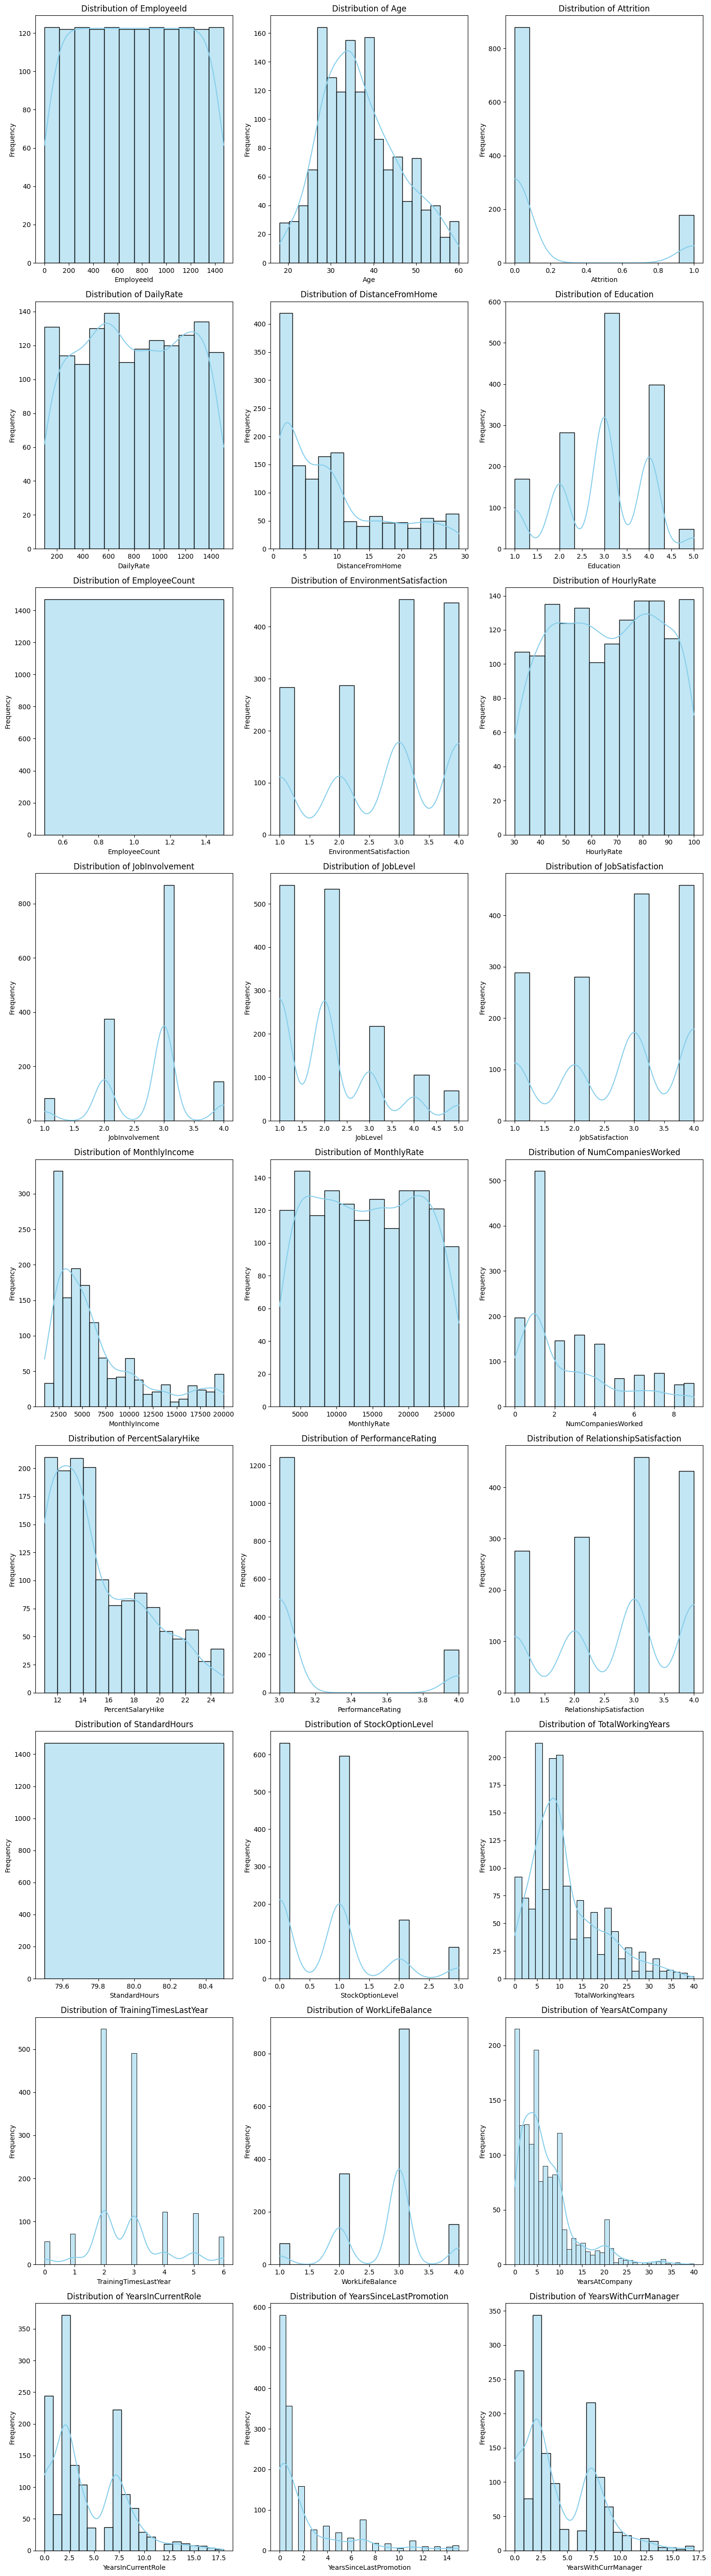

In [114]:
# Distribusi data
n_cols = len(numerical_features)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 6 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

_Insight_:
* Kolom Attrition merupakan variabel target.
* Kolom EmployeeCount dan StandardHours memiliki data yang seragam sehingga selanjutnya dapat diabaikan atau dihapus karena tidak akan berpengaruh signifikan dalam analisis.

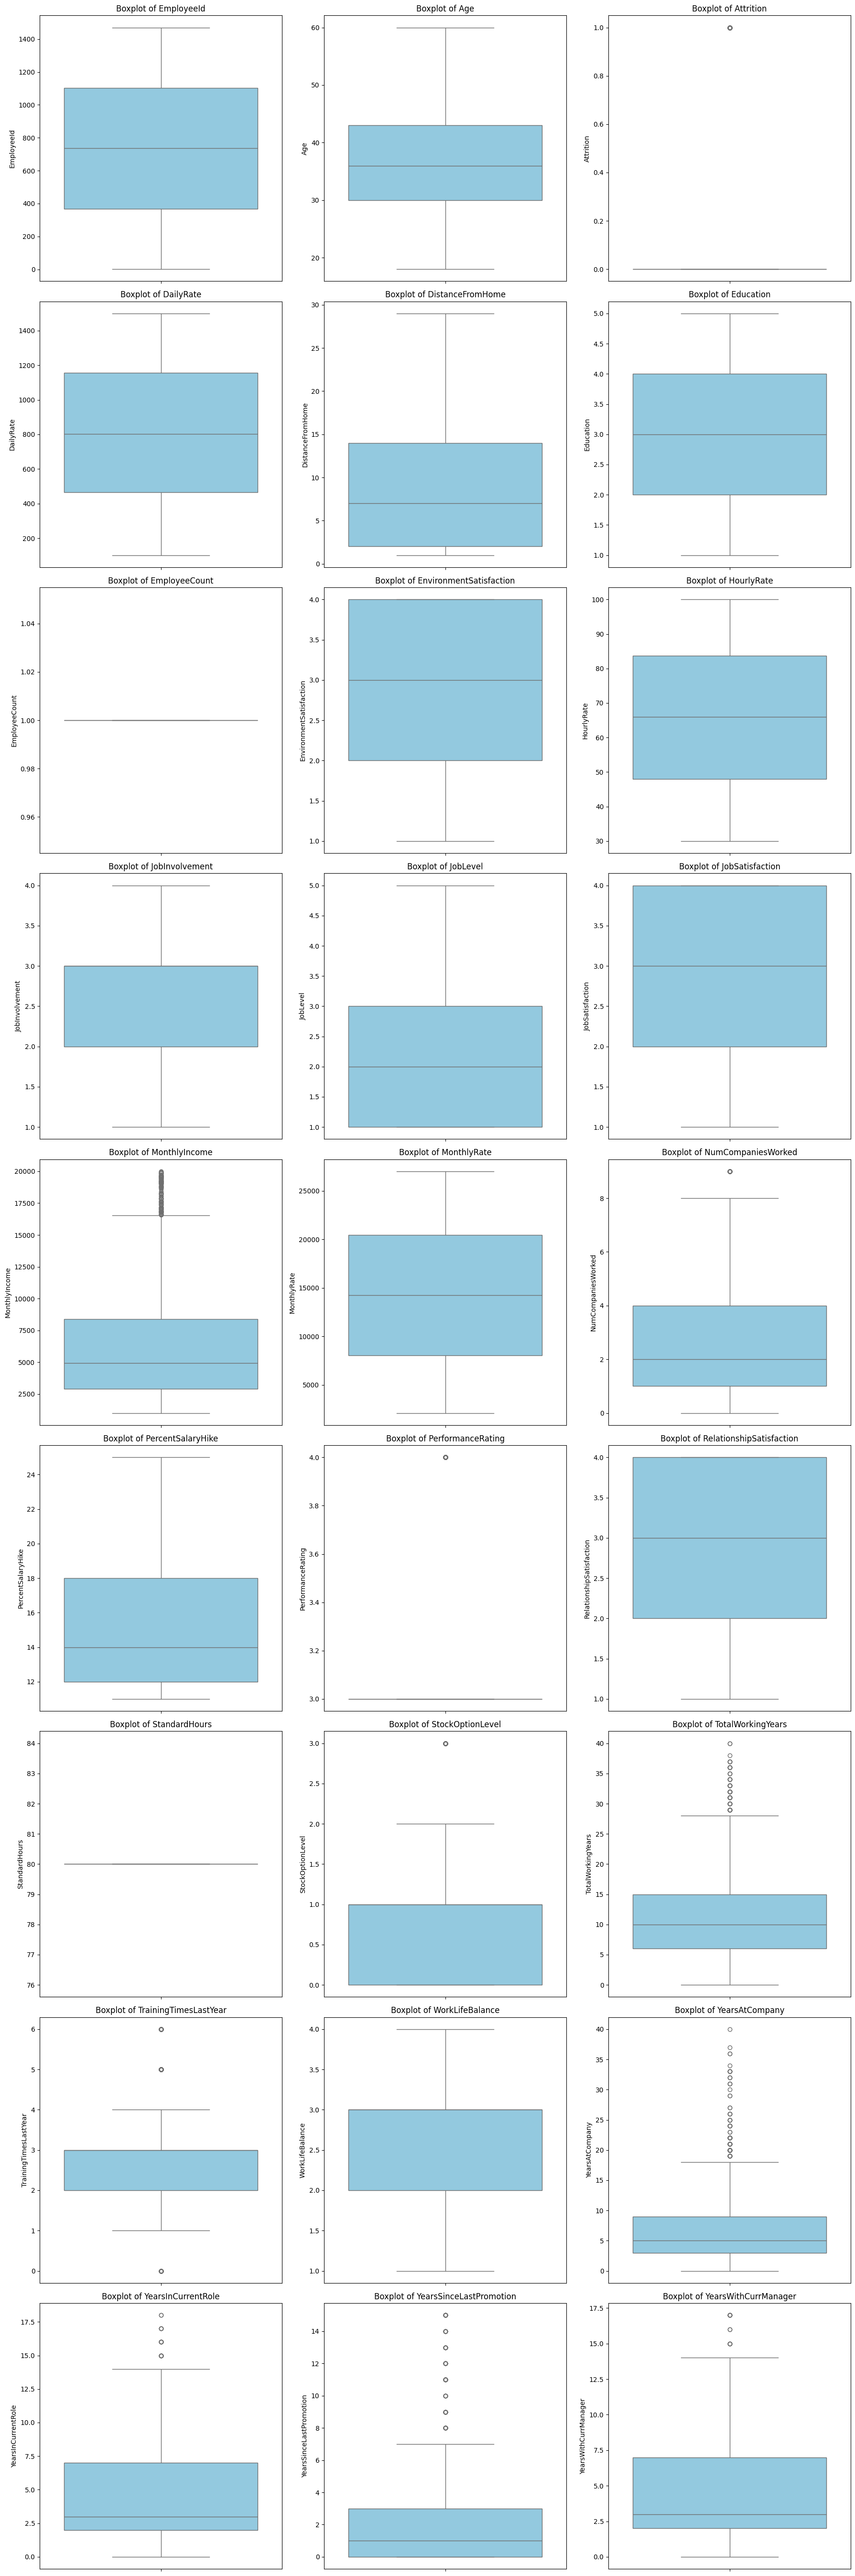

In [115]:
# Periksa outlier
n_cols = len(numerical_features)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.boxplot(data=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

_Insight_:
* Terdapat beberapa outlier antara lain pada kolom data MonthlyIncome, TotalWorkingYears, TrainingTimesLastYear, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, dan YearsWithCurrManager. Outlier seperti ini dapat dianggap wajar karena adanya perbedaan lama pengalaman kerja yang dapat memengaruhi journey seorang karyawan. Oleh karena itu, untuk sementara outlier perlu dipertahankan dalam analisis lanjutan.  

##### Kolom Kategorikal

In [116]:
# categorical features
categorical_features = df.select_dtypes(include=['object']).columns

print('Categorical features:\n', categorical_features)

Categorical features:
 Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\3082400699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\3082400699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\3082400699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\308240

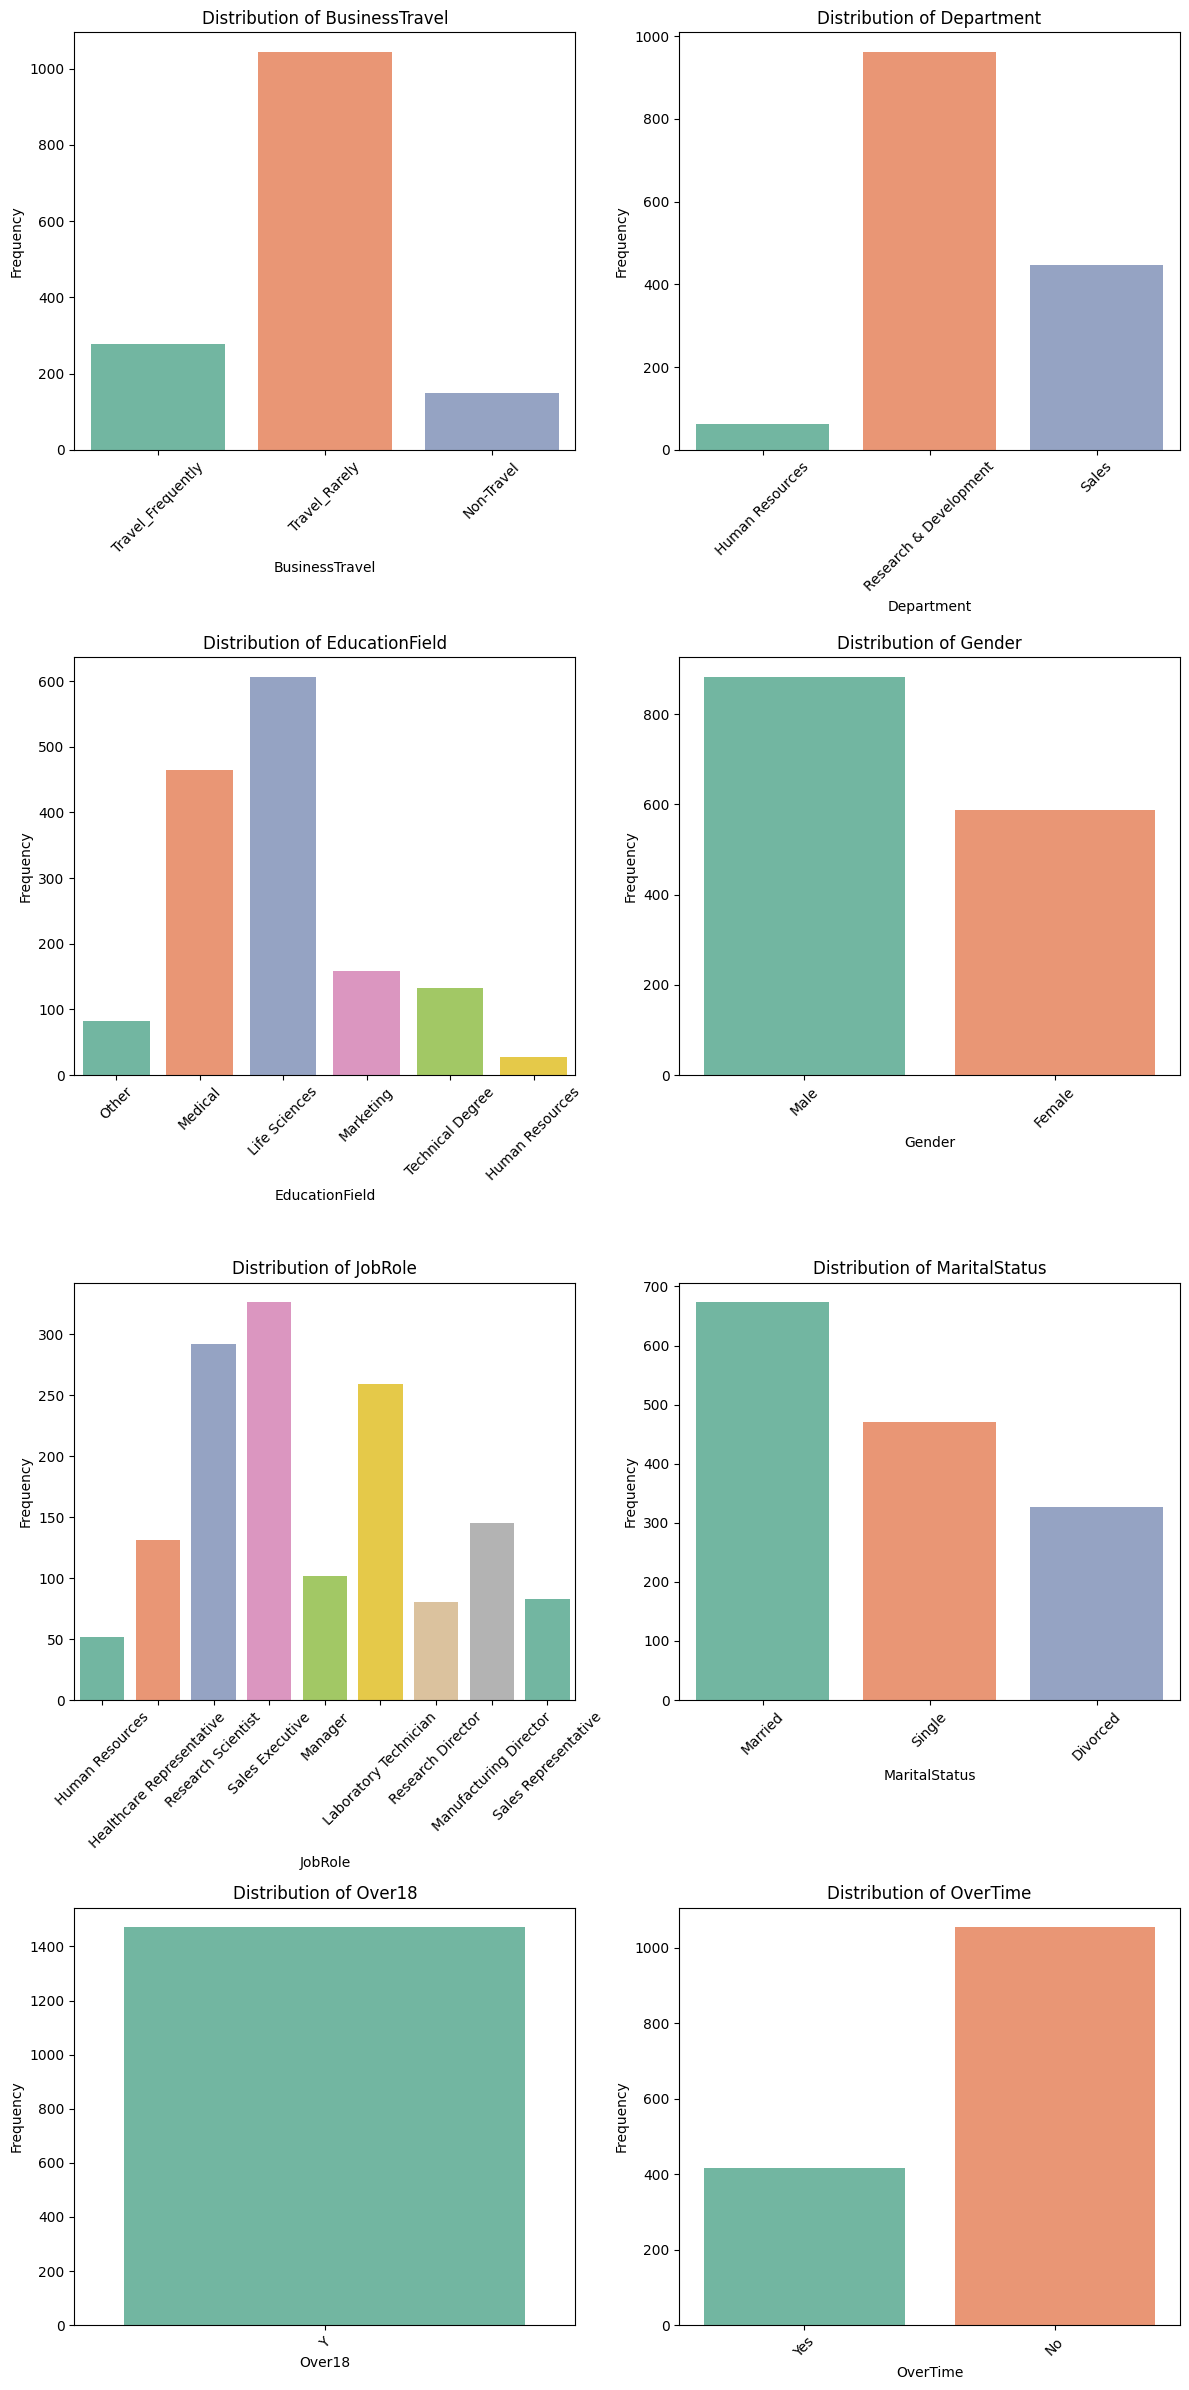

In [117]:
# countplot
cat_cols = len(categorical_features)
cat_rows = (cat_cols + 1) // 2

fig_cat, axes_cat = plt.subplots(cat_rows, 2, figsize=(12, 6 * cat_rows))
axes_cat = axes_cat.flatten()

for idx, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
    axes_cat[idx].set_title(f'Distribution of {col}')
    axes_cat[idx].set_xlabel(col)
    axes_cat[idx].set_ylabel('Frequency')
    axes_cat[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

_Insight_:
* Seluruh karyawan berusia di atas 18 tahun. Maka, kolom Over18 dapat dihapus/diabaikan dalam analisis selanjutnya karena data yang seragam tidak memiliki pengaruh signifikan terhadap variabel lain.

#### Cek Imbalance Target

C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\2353188048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='coolwarm')


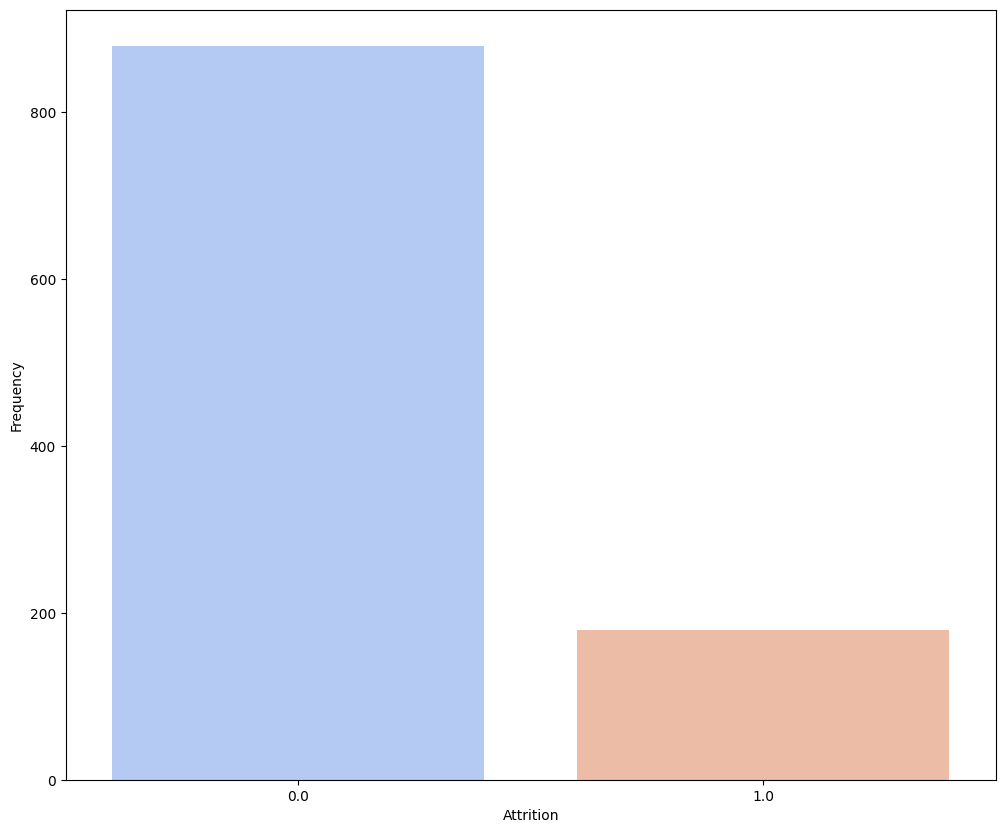

In [118]:
# Cek distribusi kolom Attrition
plt.figure(figsize=(12, 10))
sns.countplot(data=df, x='Attrition', palette='coolwarm')
plt.title('')
plt.xlabel('Attrition')
plt.ylabel('Frequency')
plt.show()

In [119]:
print(df["Attrition"].value_counts())

Attrition
0.0    879
1.0    179
Name: count, dtype: int64


In [120]:
print(f'Imbalance Ratio: {df["Attrition"].value_counts().min() / df["Attrition"].value_counts().max():.1f}')

Imbalance Ratio: 0.2


_Insight_:
* Perbandingan jumlah datanya adalah 1:5 (Imbalance Moderat) sehingga perlu dipertimbangkan penggunaan balanced class weight. 

## Data Preparation / Preprocessing

#### Missing Values Handling

In [121]:
# Missing values handling
df.dropna(inplace=True)

print('Missing values after handling:\n', df.isnull().sum().sum())

Missing values after handling:
 0


#### Feature Selection

In [122]:
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']

selected_df = df.copy().drop(columns=columns_to_drop, inplace=False)

selected_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1058 non-null   int64  
 1   Age                       1058 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1058 non-null   object 
 4   DailyRate                 1058 non-null   int64  
 5   Department                1058 non-null   object 
 6   DistanceFromHome          1058 non-null   int64  
 7   Education                 1058 non-null   int64  
 8   EducationField            1058 non-null   object 
 9   EnvironmentSatisfaction   1058 non-null   int64  
 10  Gender                    1058 non-null   object 
 11  HourlyRate                1058 non-null   int64  
 12  JobInvolvement            1058 non-null   int64  
 13  JobLevel                  1058 non-null   int64  
 14  JobRole      

#### Exploration After Preprocessing

##### Cek Korelasi Antar Variabel

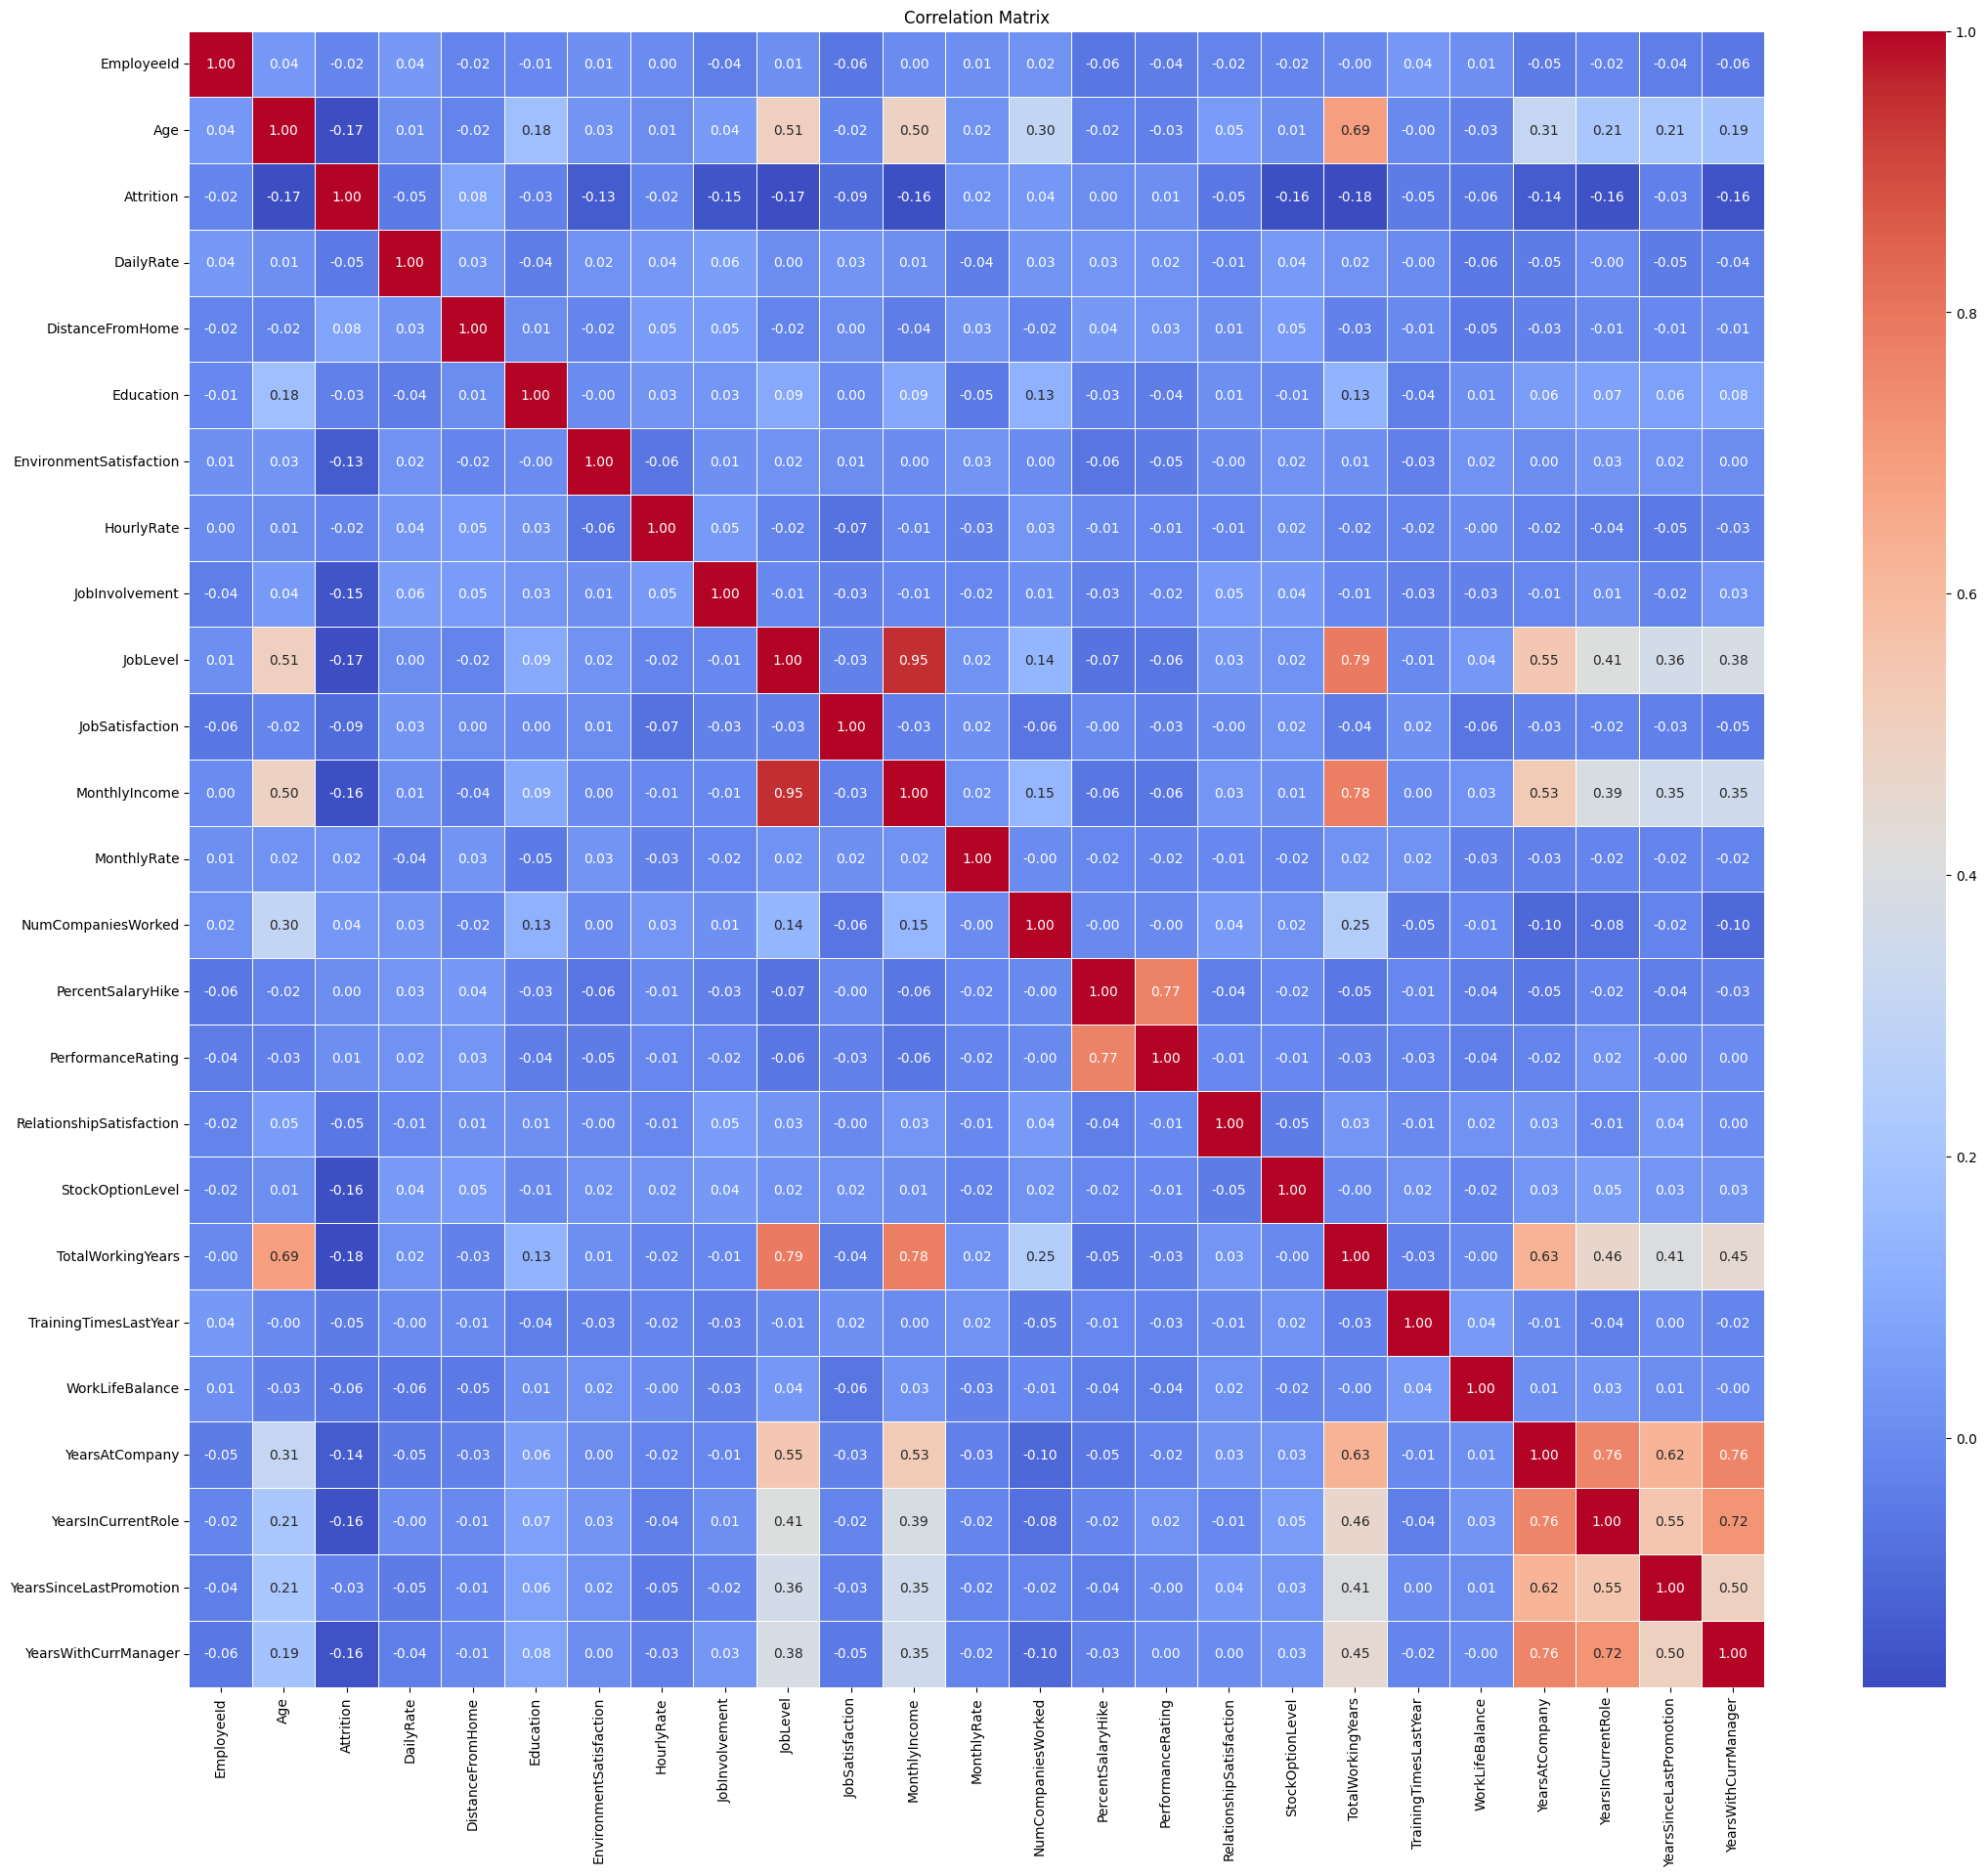

In [123]:
# Cek korelasi keseluruhan
all_corr = selected_df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')

plt.figure(figsize=(26, 22))
sns.heatmap(all_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\1151185724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_plus.values, y=top_5_plus.index, palette='coolwarm', legend=False)


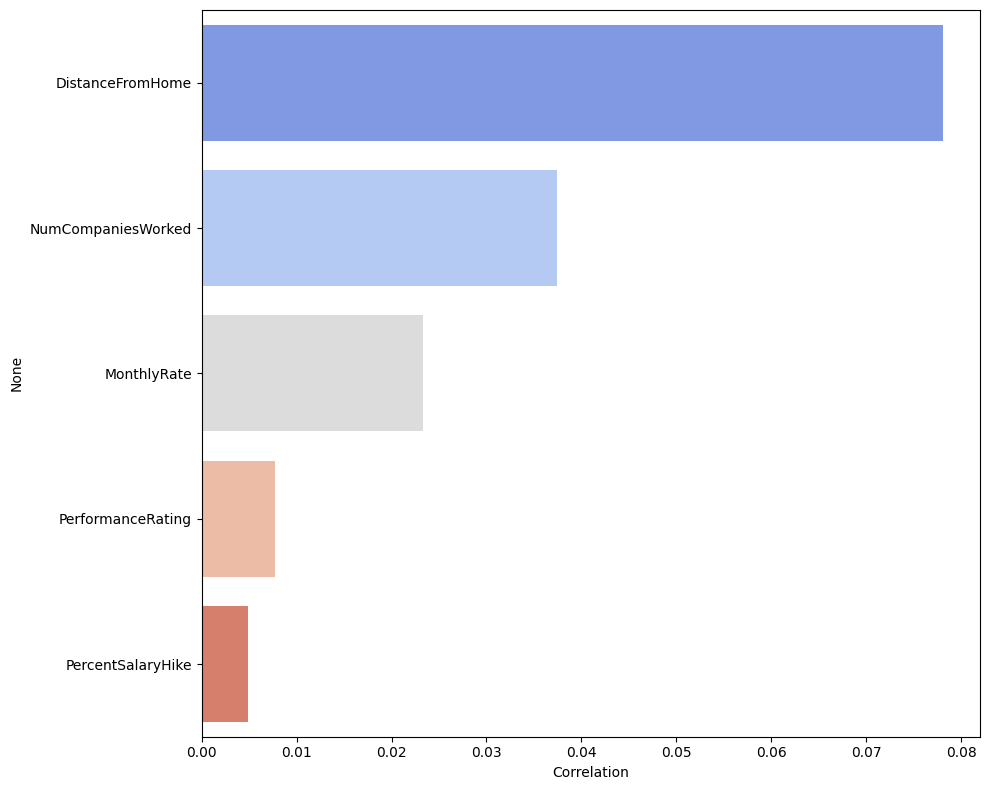

In [124]:
# Korelasi positif terhadap Attrition
top_5_plus = selected_df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')['Attrition'].drop('Attrition').sort_values(ascending=False).head()

plt.figure(figsize=(10, 8))
sns.barplot(x=top_5_plus.values, y=top_5_plus.index, palette='coolwarm', legend=False)
plt.title('')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

_Insight_:
* Aspek DistanceFromHome, NumCompaniesWorked, MonthlyRate, PerformanceRating, PercentSalaryHike memiliki korelasi positif yang paling signifikan terhadap Attrition Karyawan dibandingkan dengan aspek-aspek lainnya.

C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\3326014695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_minus.values, y=top_5_minus.index, palette='coolwarm', legend=False)


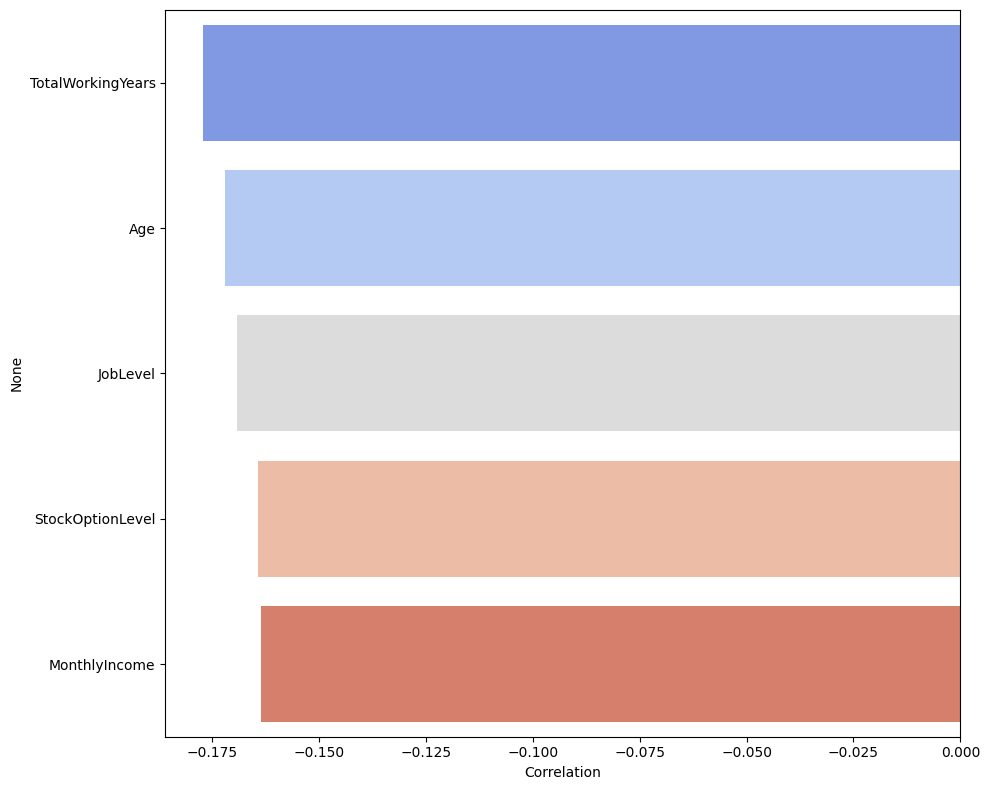

In [125]:
# Korelasi negatif terhadap Attrition
top_5_minus = selected_df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')['Attrition'].drop('Attrition').sort_values(ascending=True).head()

plt.figure(figsize=(10, 8))
sns.barplot(x=top_5_minus.values, y=top_5_minus.index, palette='coolwarm', legend=False)
plt.title('')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

_Insight_:
* Aspek MonthlyIncome, StockOptionLevel, JobLevel, Age, TotalWorkingYears memiliki korelasi negatif yang paling signifikan terhadap Attrition Karyawan dibandingkan dengan aspek-aspek lainnya.
* Perlu observasi lebih lanjut:
    - Pengaruh salary terhadap tingkat Attrition
    - Pengaruh pengalaman kerja terhadap tingkat Attrition
    - Pengaruh kepuasan dan/atau kenyamanan kerja terhadap tingkat Attrition

##### Observasi pengaruh Salary & Income terhadap Attrition

In [126]:
salary_column = ['HourlyRate', 'DailyRate', 'MonthlyRate', 'PercentSalaryHike', 'MonthlyIncome']

salary_df = selected_df.copy()
salary_df = salary_df[['EmployeeId'] + salary_column + ['Attrition']]

In [127]:
salary_bins = [0, 3000, 6000, 9000, 12000, 15000, np.inf]

salary_df['SalaryLevel'] = pd.cut(salary_df['MonthlyRate'], bins=salary_bins, labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High', 'Very High'])

salary_df['IncomeLevel'] = pd.cut(salary_df['MonthlyIncome'], bins=salary_bins, labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High', 'Very High'])

In [128]:
salary_df.head()

,EmployeeId,HourlyRate,DailyRate,MonthlyRate,PercentSalaryHike,MonthlyIncome,Attrition,SalaryLevel,IncomeLevel
1,2,61,1141,14382,15,4777,1.0,High,Medium-Low
2,3,34,1323,10332,12,2461,1.0,Medium-High,Low
3,4,77,555,14864,14,13525,0.0,High,High
6,7,57,1124,13273,22,7457,0.0,High,Medium
7,8,78,725,21199,13,19859,1.0,Very High,Very High


In [129]:
att_salary = salary_df.groupby('SalaryLevel')['Attrition'].value_counts().unstack()

att_salary

C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\2271718185.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  att_salary = salary_df.groupby('SalaryLevel')['Attrition'].value_counts().unstack()


Attrition,0.0,1.0
SalaryLevel,,
Low,36,5
Medium-Low,104,23
Medium,115,17
Medium-High,109,29
High,100,18
Very High,415,87


In [130]:
att_salary_hike = salary_df.groupby('PercentSalaryHike')['Attrition'].value_counts().unstack()

att_salary_hike

Attrition,0.0,1.0
PercentSalaryHike,,
11,130,28
12,121,24
13,122,26
14,122,19
15,58,15
16,44,11
17,50,8
18,58,12
19,43,8


In [131]:
att_income = salary_df.groupby('IncomeLevel')['Attrition'].value_counts().unstack()

att_income

C:\Users\ACER\AppData\Local\Temp\ipykernel_12228\3744345678.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  att_income = salary_df.groupby('IncomeLevel')['Attrition'].value_counts().unstack()


Attrition,0.0,1.0
IncomeLevel,,
Low,204,82
Medium-Low,303,54
Medium,144,17
Medium-High,88,16
High,43,5
Very High,97,5


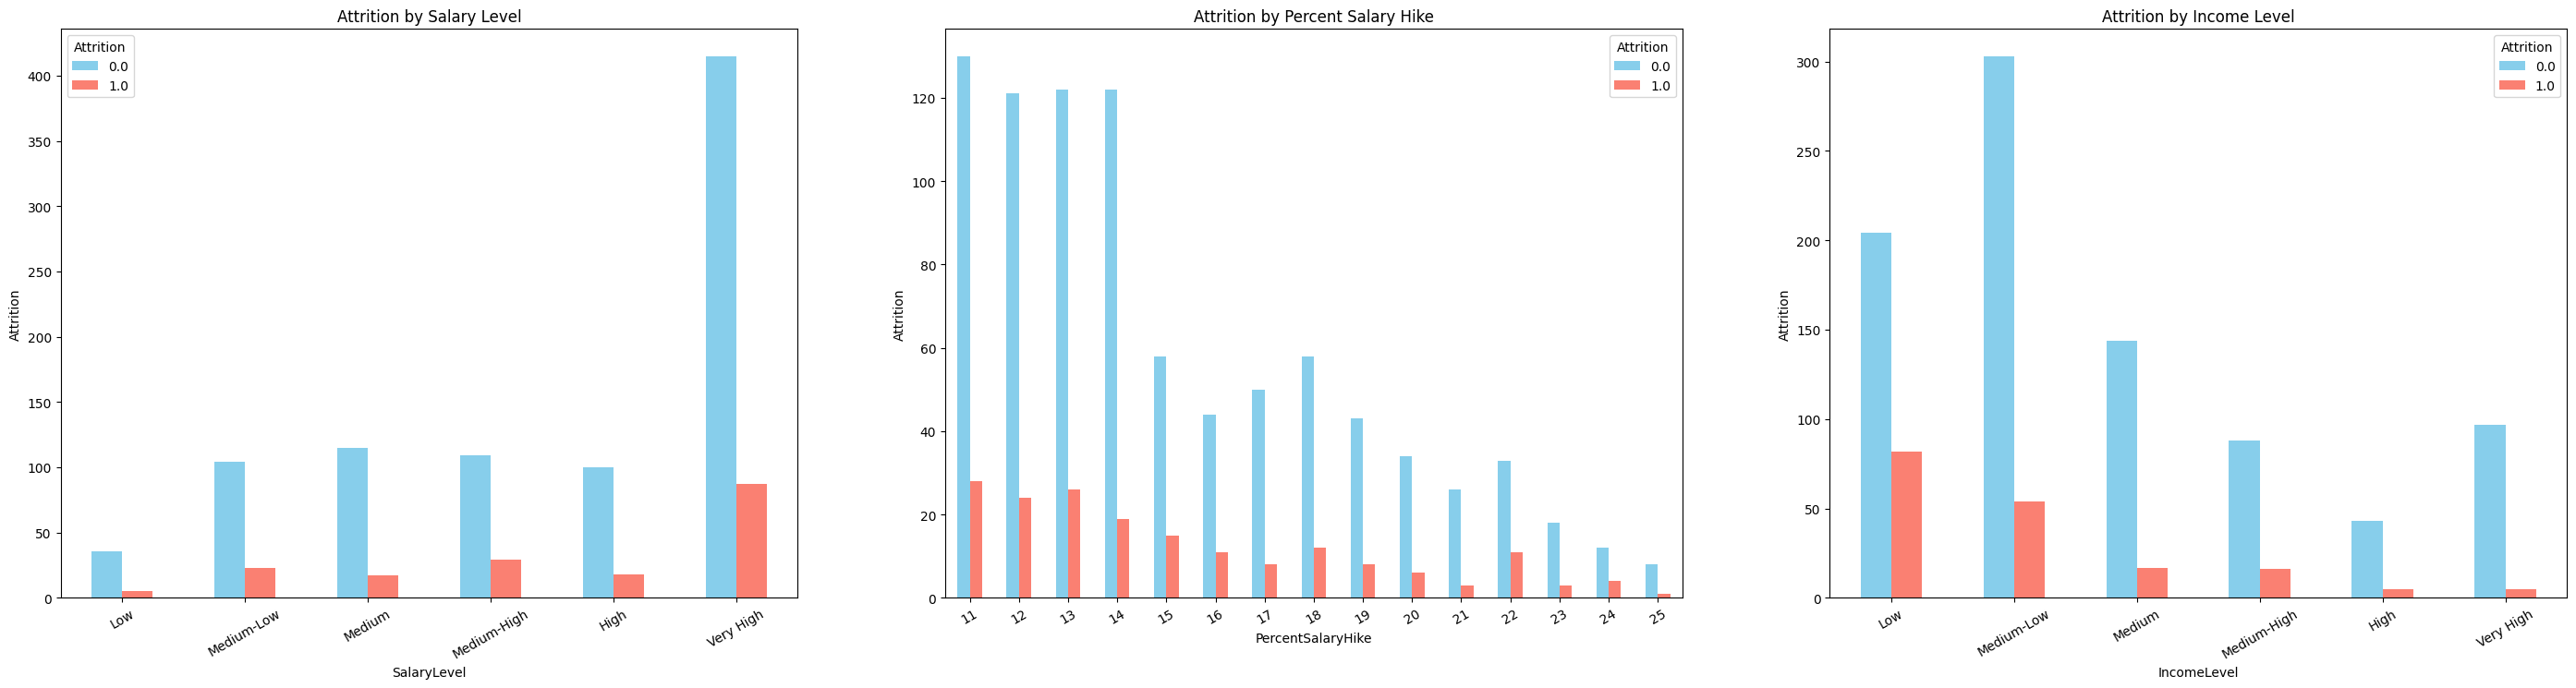

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(35, 8))

axes[0].set_title('Attrition by Salary Level')
axes[1].set_title('Attrition by Percent Salary Hike')
axes[2].set_title('Attrition by Income Level')

att_salary.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], ax=axes[0])
att_salary_hike.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], ax=axes[1])
att_income.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], ax=axes[2])

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)

axes[0].set_ylabel('Attrition')
axes[1].set_ylabel('Attrition')
axes[2].set_ylabel('Attrition')

plt.show()

_Insight_:
* Attrition rate yang tinggi tak luput dari dorongan faktor income level yang masih belum cukup/terlalu rendah untuk memenuhi kebutuhan hidup karyawan. Hal ini karena meskipun sudah mendapatkan salary yang sangat tinggi sekalipun dari perusahaan Jaya-jaya Maju ini, karyawan cenderung akan memilih peluang yang lebih baik. Apalagi jika kenaikan gaji yang mereka dapatkan terlalu kecil atau tidak sesuai dengan harapan mereka.
* Jika dikaitkan dengan aspek DistanceFromHome yang memiliki korelasi positif paling kuat terhadap Attrition, maka menjadi masuk akal. Karyawan dengan rumah yang cukup jauh dari kantor cenderung membutuhkan ongkos transportasi yang lebih mahal. Sementara di satu sisi, income yang mereka dapatkan setiap bulannya masih minimum. Bisa jadi mereka merasa resah dengan kondisi tersebut. 

##### Observasi pengaruh Pengalaman Kerja terhadap Attrition

In [147]:
work_journey_columns = [
    'BusinessTravel', 'JobInvolvement', 'JobLevel', 'NumCompaniesWorked', 
    'OverTime', 'TotalWorkingYears', 'TrainingTimesLastYear', 
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

In [148]:
journey_df = selected_df.copy()
journey_df = journey_df[['EmployeeId'] + work_journey_columns + ['Attrition']]

journey_df.head()

,EmployeeId,BusinessTravel,JobInvolvement,JobLevel,NumCompaniesWorked,OverTime,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
1,2,Travel_Rarely,1,2,5,No,15,2,1,0,0,0,1.0
2,3,Travel_Rarely,3,1,9,Yes,18,2,10,0,2,7,1.0
3,4,Travel_Frequently,3,4,5,No,23,2,20,4,4,8,0.0
6,7,Travel_Rarely,1,2,2,Yes,6,2,4,3,0,2,0.0
7,8,Travel_Rarely,3,5,5,Yes,24,2,5,2,1,4,1.0


_Insight_:
* Berdasarkan analisis sebelumnya, diketahui aspek NumCompaniesWorked dan TotalWorkingYears memiliki korelasi yang saling berkebalikan terhadap Attrition.

In [163]:
journey_df['NumCompaniesWorked'].value_counts().sort_index()

NumCompaniesWorked
0    147
1    371
2    100
3    116
4     97
5     48
6     50
7     58
8     28
9     43
Name: count, dtype: int64

In [161]:
att_numcompworked = journey_df.groupby('NumCompaniesWorked')['Attrition'].value_counts().unstack()

att_numcompworked.sort_values(by=1, ascending=False)

Attrition,0.0,1.0
NumCompaniesWorked,,
1,297,74
0,128,19
5,35,13
7,45,13
2,88,12
4,85,12
3,105,11
6,39,11
9,34,9


In [159]:
journey_df['TotalWorkingYears'].value_counts().sort_index()

TotalWorkingYears
0       9
1      57
2      25
3      32
4      44
5      67
6      89
7      58
8      77
9      65
10    135
11     22
12     37
13     27
14     17
15     23
16     27
17     28
18     20
19     15
20     23
21     25
22     20
23     16
24     12
25     10
26     13
27      2
28     12
29      7
30      6
31      9
32      7
33      7
34      3
35      2
36      4
37      3
38      1
40      2
Name: count, dtype: int64

In [162]:
att_totworkyears = journey_df.groupby('TotalWorkingYears')['Attrition'].value_counts().unstack()

att_totworkyears.sort_values(by=1, ascending=False)

Attrition,0.0,1.0
TotalWorkingYears,,
1,29.0,28.0
10,117.0,18.0
6,73.0,16.0
7,44.0,14.0
8,63.0,14.0
5,54.0,13.0
9,55.0,10.0
4,35.0,9.0
3,24.0,8.0


In [165]:
journey_df['YearsAtCompany'].value_counts().sort_index()

YearsAtCompany
0      31
1     128
2      88
3      98
4      75
5     133
6      57
7      64
8      65
9      60
10     79
11     23
12     11
13     17
14     11
15     12
16      8
17      8
18     11
19      9
20     20
21     11
22      9
24      6
25      4
26      3
27      2
29      2
31      3
32      2
33      4
34      1
36      1
37      1
40      1
Name: count, dtype: int64

In [167]:
att_yearsatcomp = journey_df.groupby('YearsAtCompany')['Attrition'].value_counts().unstack(fill_value=0)

att_yearsatcomp.sort_values(by=1, ascending=False)

Attrition,0.0,1.0
YearsAtCompany,,
1,84,44
2,69,19
3,80,18
5,118,15
4,61,14
10,66,13
0,20,11
7,55,9
6,49,8


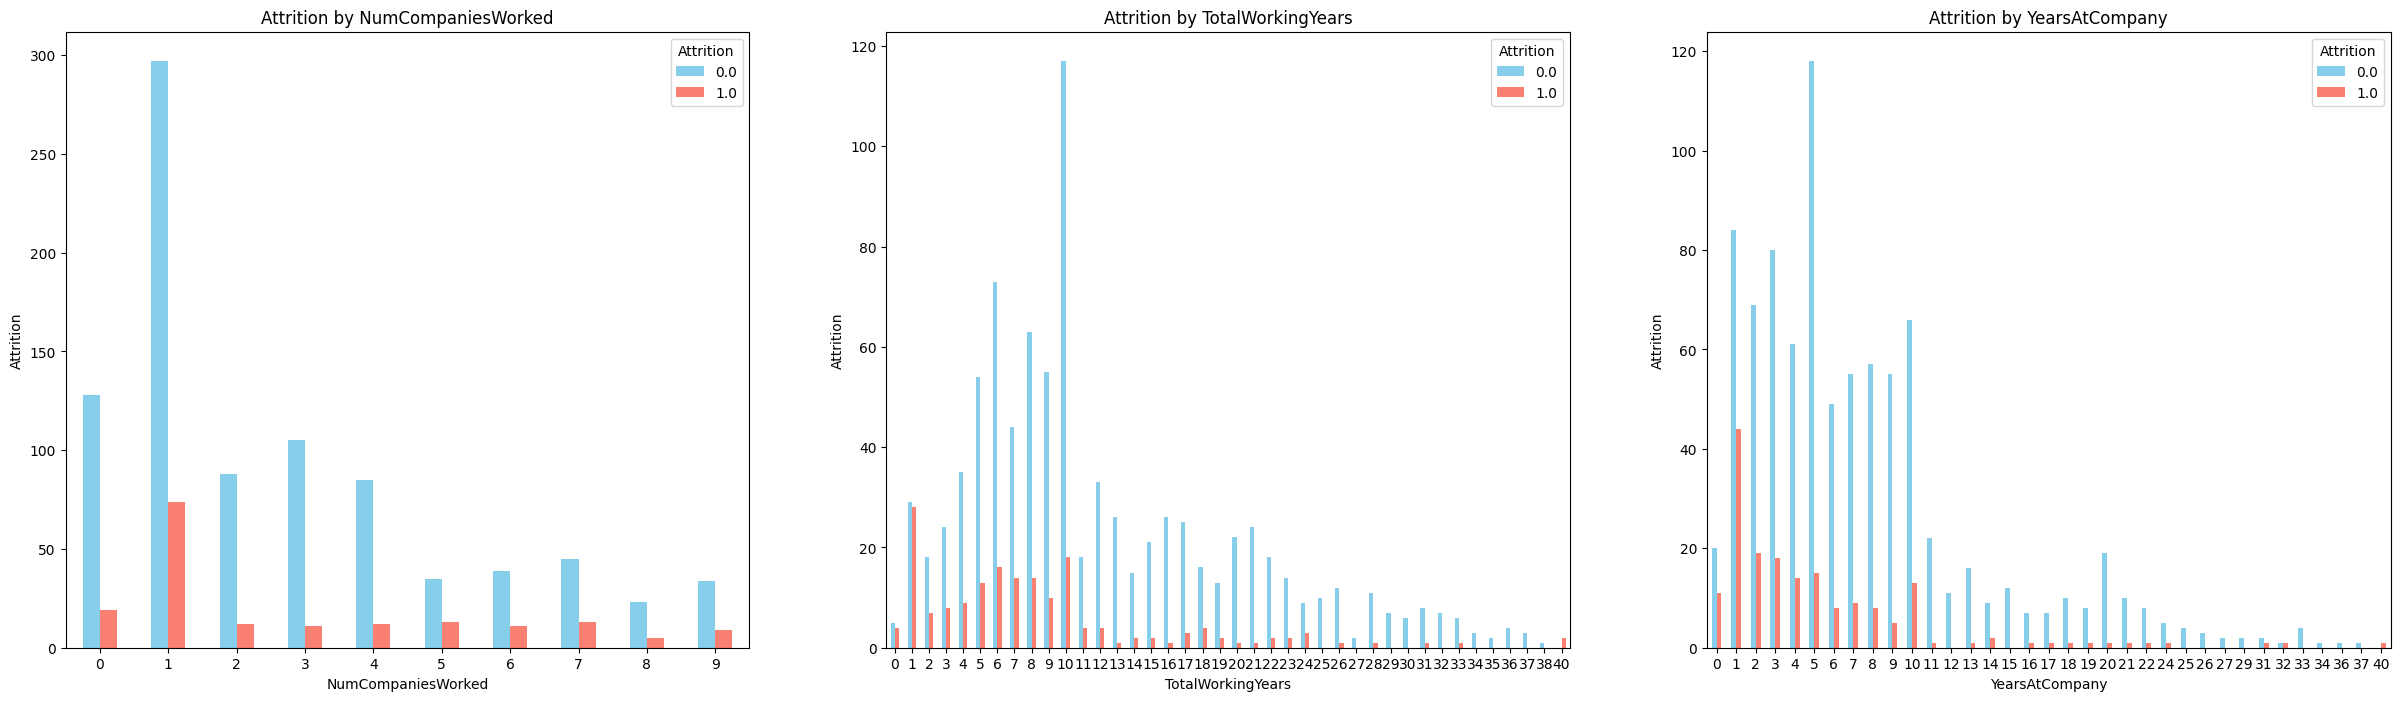

In [174]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

axes[0].set_title('Attrition by NumCompaniesWorked')
axes[1].set_title('Attrition by TotalWorkingYears')
axes[2].set_title('Attrition by YearsAtCompany')

att_numcompworked.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], ax=axes[0])
att_totworkyears.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], ax=axes[1])
att_yearsatcomp.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'], ax=axes[2])

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

axes[0].set_ylabel('Attrition')
axes[1].set_ylabel('Attrition')
axes[2].set_ylabel('Attrition')

plt.show()

_Insight_:
* Berdasarkan NumCompaniesWorked, karyawan yang banyak berhenti atau bisa jadi diberhentikan didominasi oleh individu yang sebelumnya baru pernah bekerja di 1 perusahaan atau belum pernah bekerja sama sekali.
* Berdasarkan TotalWorkingYears, karyawan yang mendorong tingginya tingkat Attration didominasi oleh karyawan dengan pengalaman kerja tidak lebih dari 10 tahun. 
* Berdasarkan YearsAtCompany, karyawan dengan usia kerja (di perusahaan Jaya-jaya Maju) selama 10 tahun atau kurang yang berhenti atau bisa jadi diberhentikan jumlahnya sangat banyak. 
* Talent dengan pengalaman kerja selama 1 tahun paling rentan untuk berhenti atau diberhentikan.
* Ada banyak hal yang mungkin jadi alasan, misalnya ketidaksesuaian performa talent dengan kebutuhan perusahaan, ekspektasi kerja talent yang tidak tercukupi, talent hanya menjadikan pekerjaan pertamanya sebagai batu loncatan, atau terdapat peluang kerja yang lebih bagus yang ditawarkan oleh perusahaan lain.

##### Observasi pengaruh Kepuasan/Kenyamanan Kerja terhadap Attrition 

##### Cek Attration Rate setiap Department

In [149]:
att_dep = df.groupby('Department')['Attrition'].value_counts().unstack()

att_dep

Attrition,0.0,1.0
Department,,
Human Resources,32,6
Research & Development,594,107
Sales,253,66


<Figure size 1200x1000 with 0 Axes>

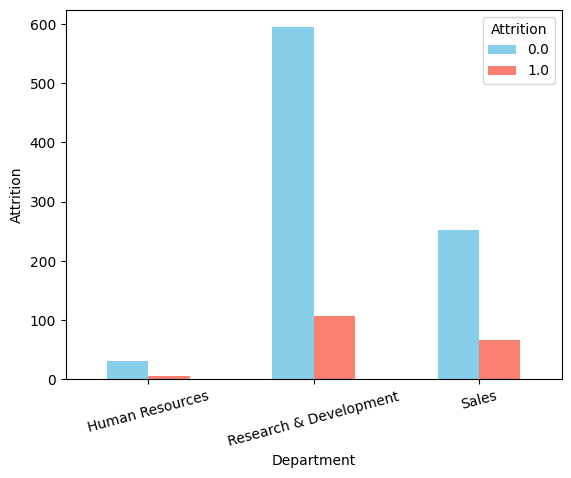

In [156]:
plt.figure(figsize=(12, 10))
att_dep.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'])
plt.title('')
plt.xlabel('Department')
plt.xticks(rotation=15)
plt.ylabel('Attrition')
plt.show()

##### Cek Attration Rate berdasarkan Job Role

In [154]:
att_role = df.groupby('JobRole')['Attrition'].value_counts().unstack()

att_role

Attrition,0.0,1.0
JobRole,,
Healthcare Representative,80,8
Human Resources,24,6
Laboratory Technician,139,49
Manager,74,5
Manufacturing Director,100,7
Research Director,60,2
Research Scientist,176,38
Sales Executive,193,39
Sales Representative,33,25


<Figure size 1200x1000 with 0 Axes>

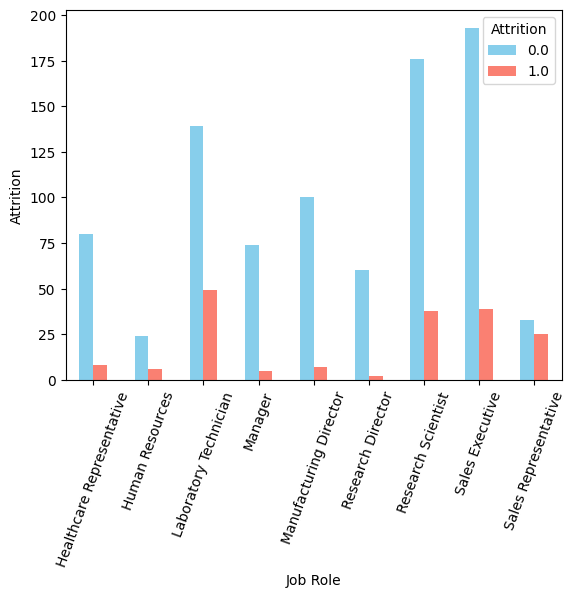

In [162]:
plt.figure(figsize=(12, 10))
att_role.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'])
plt.title('')
plt.xlabel('Job Role')
plt.xticks(rotation=70)
plt.ylabel('Attrition')
plt.show()

##### Cek Attration Rate berdasarkan Education Level

In [167]:
edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}

edu_df = df.copy()
edu_df['Education'] = edu_df['Education'].map(edu_map)

In [168]:
edu_df['Education'].value_counts()

Education
Bachelor         410
Master           276
College          208
Below College    131
Doctor            33
Name: count, dtype: int64

In [170]:
att_edu = edu_df.groupby('Education')['Attrition'].value_counts().unstack()

att_edu

Attrition,0.0,1.0
Education,,
Bachelor,334,76
Below College,105,26
College,177,31
Doctor,31,2
Master,232,44


<Figure size 1200x1000 with 0 Axes>

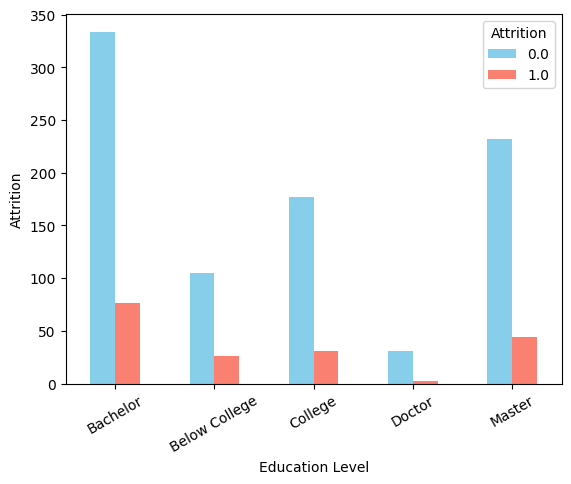

In [173]:
plt.figure(figsize=(12, 10))
att_edu.plot(kind='bar', stacked=False, color=['skyblue', 'salmon'])
plt.title('')
plt.xlabel('Education Level')
plt.xticks(rotation=30)
plt.ylabel('Attrition')
plt.show()

#### Encoding

* Encoding dilakukan untuk menyesuaikan data agar memiliki tipe yang seragam, yaitu numerik, sehingga dapat memudahkan dalam analisis korelasi antar variabel.

In [ ]:
encoders = {}

for col in categorical_features:
    if col not in column_to_drop:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

#### Data Split

In [132]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### Handling Imbalance Data (Opsional)

In [134]:
# SMOTE untuk training set
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(k_neighbors=5, random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

## Modeling

In [135]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=4,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [136]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=4,
                       min_samples_split=10, n_jobs=-1, random_state=42)

## Evaluation

In [137]:
y_pred = model_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.95      0.92       176
         1.0       0.64      0.39      0.48        36

    accuracy                           0.86       212
   macro avg       0.76      0.67      0.70       212
weighted avg       0.84      0.86      0.84       212



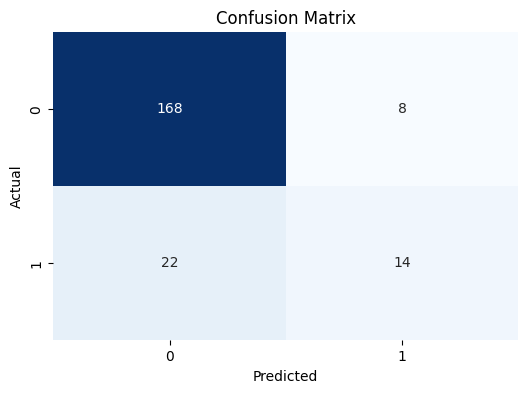

In [138]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [139]:
# feature importance
feature_importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': model_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
21,OverTime,0.075782
1,Age,0.072375
26,StockOptionLevel,0.065670
17,MonthlyIncome,0.063234
27,TotalWorkingYears,0.053532
18,MonthlyRate,0.044741
3,DailyRate,0.043625
13,JobLevel,0.041983
5,DistanceFromHome,0.041316
0,EmployeeId,0.040050


## Export

In [140]:
# save model
joblib.dump(model_rf, 'model.pkl')

['model.pkl']

In [ ]:
# inverse transform df
for col in categorical_features:
    le = encoders[col]
    df[col] = le.inverse_transform(df[col])

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,...,3,80,3,6,2,2,4,3,0,2
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,...,4,80,1,24,2,3,5,2,1,4


In [144]:
df.head().T

,1,2,3,6,7
EmployeeId,2,3,4,7,8
Age,37,51,42,40,55
Attrition,1.0,1.0,0.0,0.0,1.0
BusinessTravel,Travel_Rarely,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Rarely
DailyRate,1141,1323,555,1124,725
Department,Research & Development,Research & Development,Sales,Sales,Research & Development
DistanceFromHome,11,4,26,1,2
Education,2,4,3,2,3
EducationField,Medical,Life Sciences,Marketing,Medical,Medical
EmployeeCount,1,1,1,1,1


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1058 non-null   int64  
 1   Age                       1058 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1058 non-null   object 
 4   DailyRate                 1058 non-null   int64  
 5   Department                1058 non-null   object 
 6   DistanceFromHome          1058 non-null   int64  
 7   Education                 1058 non-null   int64  
 8   EducationField            1058 non-null   object 
 9   EmployeeCount             1058 non-null   int64  
 10  EnvironmentSatisfaction   1058 non-null   int64  
 11  Gender                    1058 non-null   object 
 12  HourlyRate                1058 non-null   int64  
 13  JobInvolvement            1058 non-null   int64  
 14  JobLevel     

In [142]:
# save cleaned data
df.to_csv('cleaned_employee_data.csv', index=False)